# Laboratorium 10. (Faktoryzacja QR)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.linalg import cond, lstsq, norm, qr

## 1. Faktoryzacja QR metodą Grama-Schmidta

### 1.1. Implementacja

In [2]:
def gram_schmidt_qr(A):
    Q = np.zeros(A.shape)
    R = np.zeros((A.shape[1], A.shape[1]))

    for k in range(A.shape[1]):
        u_k = A[:, k].copy()

        for i in range(k):
            R[i, k] = np.dot(Q[:, i], A[:, k])
            u_k = u_k - R[i, k] * Q[:, i]

        R[k, k] = np.linalg.norm(u_k)
        Q[:, k] = u_k / R[k, k]

    return Q, R

### 1.2. Funkcja odpowiadająca za wizualizację wyników

In [3]:
def visualize_results(stability_results):
    plt.figure(figsize=(8, 8))

    cond_nums = [r["condition_number"] for r in stability_results]
    orth_errors = [r["orthogonality_error"] for r in stability_results]
    plt.plot(cond_nums, orth_errors)
    plt.xlabel("Condition number")
    plt.ylabel("Orthogonality error ||I - Q^T Q||")
    plt.title("Stability vs conditioning")
    plt.grid(True)

    plt.show()

### 1.3. Funkcje testujące

In [4]:
def test_random_matrices():
    results = []

    for size in [5, 10, 15, 20, 25]:
        A = np.random.randn(size, size)

        Q_custom, R_custom = gram_schmidt_qr(A)
        Q_numpy, R_numpy = qr(A)

        error_Q = norm(Q_custom @ Q_custom.T - np.eye(size))
        error_Q_np = norm(Q_numpy @ Q_numpy.T - np.eye(size))
        error_reconstruction = norm(A - Q_custom @ R_custom)
        error_reconstruction_np = norm(A - Q_numpy @ R_numpy)
        error_vs_numpy_Q = norm(abs(Q_custom) - abs(Q_numpy))
        error_vs_numpy_R = norm(abs(R_custom) - abs(R_numpy))

        results.append(
            {
                "size": size,
                "error_orthogonality": error_Q,
                "err_ort_np": error_Q_np,
                "error_reconstruction": error_reconstruction,
                "err_rec_np": error_reconstruction_np,
                "error_vs_numpy_Q": error_vs_numpy_Q,
                "error_vs_numpy_R": error_vs_numpy_R,
                "cond_A": cond(A),
            }
        )

    return results


def generate_condition_matrices():
    matrices = []

    for i in range(30):
        U, S, V = np.linalg.svd(np.random.randint(-10, 10, size = (8, 8)))
        S = np.linspace(1, 1+i*10, 8)
        A = U @ np.diag(S) @ V
        matrices.append(A)

    return matrices


def analyze_qr_stability(matrices):
    results = []

    for A in matrices:
        Q_custom, _ = gram_schmidt_qr(A)

        error_orthogonality = norm(Q_custom @ Q_custom.T - np.eye(A.shape[0]))
        condition_A = cond(A)

        results.append(
            {
                "condition_number": condition_A,
                "orthogonality_error": error_orthogonality,
            }
        )

    return results

### 1.4. Wyniki

Test on random matrices:
5x5 matrix:
  Q orthogonality error: 3.95e-15 (Numpy: 8.04e-16)
  A reconstruction error: 3.24e-16 (Numpy: 1.21e-15)
  Difference vs NumPy Q: 2.97e-15
  Difference vs NumPy R: 2.26e-15
  Condition number of A: 15.82

10x10 matrix:
  Q orthogonality error: 1.42e-15 (Numpy: 1.12e-15)
  A reconstruction error: 8.04e-16 (Numpy: 2.48e-15)
  Difference vs NumPy Q: 1.28e-15
  Difference vs NumPy R: 2.11e-15
  Condition number of A: 6.80

15x15 matrix:
  Q orthogonality error: 1.36e-14 (Numpy: 2.36e-15)
  A reconstruction error: 1.78e-15 (Numpy: 6.21e-15)
  Difference vs NumPy Q: 1.00e-14
  Difference vs NumPy R: 6.13e-15
  Condition number of A: 61.44

20x20 matrix:
  Q orthogonality error: 6.60e-14 (Numpy: 2.29e-15)
  A reconstruction error: 3.50e-15 (Numpy: 8.51e-15)
  Difference vs NumPy Q: 4.49e-14
  Difference vs NumPy R: 2.30e-14
  Condition number of A: 235.63

25x25 matrix:
  Q orthogonality error: 5.96e-14 (Numpy: 3.03e-15)
  A reconstruction error: 4.04e-15 

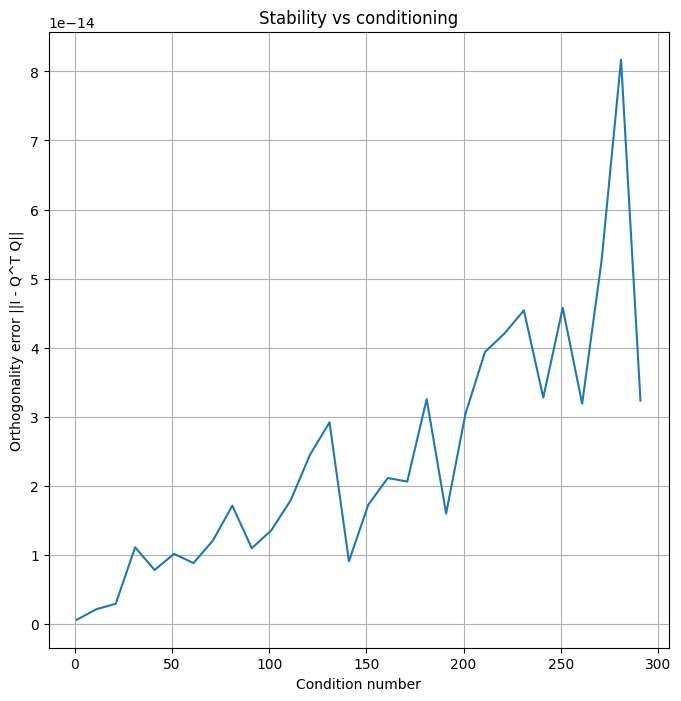

In [5]:
print("Test on random matrices:")
random_results = test_random_matrices()

for result in random_results:
    print(f"{result['size']}x{result['size']} matrix:")
    print(f"  Q orthogonality error: {result['error_orthogonality']:.2e} (Numpy: {result['err_ort_np']:.2e})")
    print(f"  A reconstruction error: {result['error_reconstruction']:.2e} (Numpy: {result['err_rec_np']:.2e})")
    print(f"  Difference vs NumPy Q: {result['error_vs_numpy_Q']:.2e}")
    print(f"  Difference vs NumPy R: {result['error_vs_numpy_R']:.2e}")
    print(f"  Condition number of A: {result['cond_A']:.2f}")
    print()

matrices = generate_condition_matrices()
stability_results = analyze_qr_stability(matrices)

visualize_results(stability_results)

## 2. Rozwiązywanie układów równań metodą QR

### 2.1. Funkcja rozwiązująca układ równań

In [6]:
def solve(A, b):
    Q, R = gram_schmidt_qr(A)
    return np.linalg.inv(R) @ Q.T @ b

### 2.2. Wizualizacja wyników

In [7]:
def visualize_polynomial_fit(x_data, y_data, x_plot, y_qr, y_numpy):

    plt.figure(figsize=(8, 6))

    plt.plot(x_data, y_data, "ro", markersize=8, label="Data points")
    plt.plot(x_plot, y_qr, "b-", linewidth=2, label="QR method")
    plt.plot(x_plot, y_numpy, "g--", linewidth=2, label="NumPy lstsq")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Polynomial Approximation")
    plt.legend()
    plt.grid(True)

    plt.show()

### 2.3. Wyniki

Polynomial approximation using QR method

Model: f(x) = α₀ + α₁x + α₂x²

QR method coefficients:
α₀ = 13.972028
α₁ = 0.181818
α₂ = -0.433566

NumPy lstsq coefficients:
α₀ = 13.972028
α₁ = 0.181818
α₂ = -0.433566

Difference between methods:
Δα₀ = 7.11e-15
Δα₁ = 1.11e-16
Δα₂ = 1.67e-16

RMS error (QR method): 0.384043
RMS error (NumPy lstsq): 0.384043


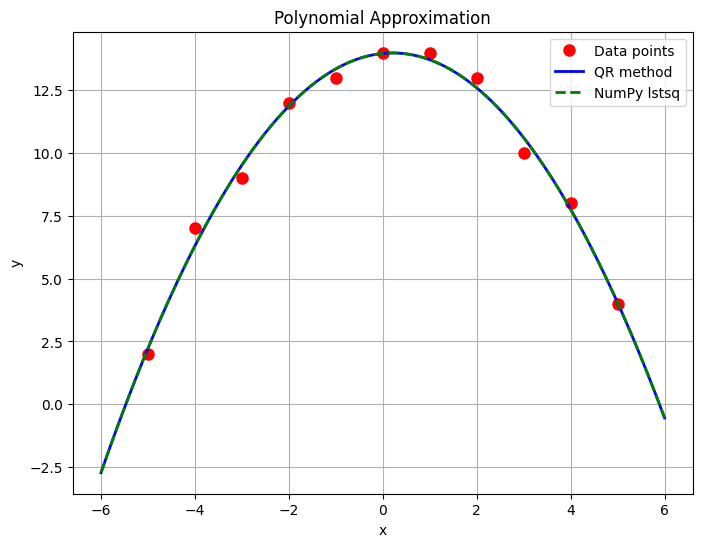

In [8]:
x_data = np.array([-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5])
y_data = np.array([2, 7, 9, 12, 13, 14, 14, 13, 10, 8, 4])

A = np.column_stack([np.ones(len(x_data)), x_data, x_data**2])

coeffs_qr = solve(A, y_data)

coeffs_numpy = lstsq(A, y_data, rcond=None)[0]

print("Polynomial approximation using QR method\n")
print("Model: f(x) = α₀ + α₁x + α₂x²")
print()

print("QR method coefficients:")
print(f"α₀ = {coeffs_qr[0]:.6f}")
print(f"α₁ = {coeffs_qr[1]:.6f}")
print(f"α₂ = {coeffs_qr[2]:.6f}")
print()

print("NumPy lstsq coefficients:")
print(f"α₀ = {coeffs_numpy[0]:.6f}")
print(f"α₁ = {coeffs_numpy[1]:.6f}")
print(f"α₂ = {coeffs_numpy[2]:.6f}")
print()

diff = np.abs(coeffs_qr - coeffs_numpy)
print("Difference between methods:")
print(f"Δα₀ = {diff[0]:.2e}")
print(f"Δα₁ = {diff[1]:.2e}")
print(f"Δα₂ = {diff[2]:.2e}")
print()

residuals_qr = A @ coeffs_qr - y_data
residuals_numpy = A @ coeffs_numpy - y_data

rms_qr = np.sqrt(np.mean(residuals_qr**2))
rms_numpy = np.sqrt(np.mean(residuals_numpy**2))

print(f"RMS error (QR method): {rms_qr:.6f}")
print(f"RMS error (NumPy lstsq): {rms_numpy:.6f}")

x_plot = np.linspace(-6, 6, 200)
y_qr = coeffs_qr[0] + coeffs_qr[1] * x_plot + coeffs_qr[2] * x_plot**2
y_numpy = coeffs_numpy[0] + coeffs_numpy[1] * x_plot + coeffs_numpy[2] * x_plot**2

visualize_polynomial_fit(
    x_data,
    y_data,
    x_plot,
    y_qr,
    y_numpy
)